In [1]:
import sys, pathlib
_here = pathlib.Path.cwd().resolve()
for _p in [_here, *_here.parents]:
    if (_p / "src" / "ml_textbook").exists():
        sys.path.insert(0, str(_p / "src"))
        break

# 09. モデルの解釈 — なぜその予測になったのか

> 各章は **直感 → 最小限の数式 → scikit-learn 実装 → 可視化 → 実験 → 演習** の順。本文は日本語、コードは英語、数式に日本語を入れない。

## この章で分かること

- 係数 / 木の重要度 / **permutation importance** で「効いている特徴」を読む
- **部分依存 (PDP)** と **ICE** で「特徴を動かすと予測がどう動くか」を見る
- **相関した特徴** が重要度・係数を不安定にすること
- **相関 ≠ 因果**: 解釈ツールは「モデルの振る舞い」を説明するが、現実の因果ではない
- 反実仮想(counterfactual)的な「何を変えれば予測が変わるか」の見方

> この章の主張: **「解釈ツールはモデルの挙動を説明する。世界の因果を説明するとは限らない。」**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio
import plotly.graph_objects as go
pio.renderers.default = "plotly_mimetype+notebook_connected"

from ml_textbook import datasets, plotting, interpretation

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)

# California housing (regression). Subsample for snappy interpretation plots.
cal = datasets.load_california_housing_dataset()
rng = np.random.default_rng(0)
idx = rng.choice(len(cal.data), 2000, replace=False)
Xc = cal.data.iloc[idx].reset_index(drop=True)
yc = cal.target.iloc[idx].reset_index(drop=True)
print("features:", list(Xc.columns))

features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## 1. 係数の解釈(線形モデル)

特徴を **標準化** してから線形回帰すると、係数の大きさを直接比較できます。
正の係数は「その特徴が大きいほど予測(住宅価格)が上がる」ことを意味します。
ただし強く相関した特徴があると、係数は不安定になります(後述)。

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

lin = make_pipeline(StandardScaler(), LinearRegression()).fit(Xc, yc)
coef = lin.named_steps["linearregression"]
table = interpretation.coefficient_table(coef, Xc.columns)
print(table.to_string(index=False))

   feature  coefficient  abs_coefficient
  Latitude    -0.934725         0.934725
 Longitude    -0.867625         0.867625
    MedInc     0.764589         0.764589
  AveOccup    -0.248972         0.248972
 AveBedrms     0.153001         0.153001
  HouseAge     0.133672         0.133672
  AveRooms    -0.115098         0.115098
Population     0.053983         0.053983


## 2. 木の重要度 vs permutation importance

`feature_importances_`(不純度ベース)は速いが、**連続値・高カーディナリティ特徴を過大評価** する偏りがあります。
**permutation importance** は、特徴をシャッフルして **検証スコアがどれだけ落ちるか** を測る方法で、
モデル非依存・偏りが小さい。両方を並べて比べます。

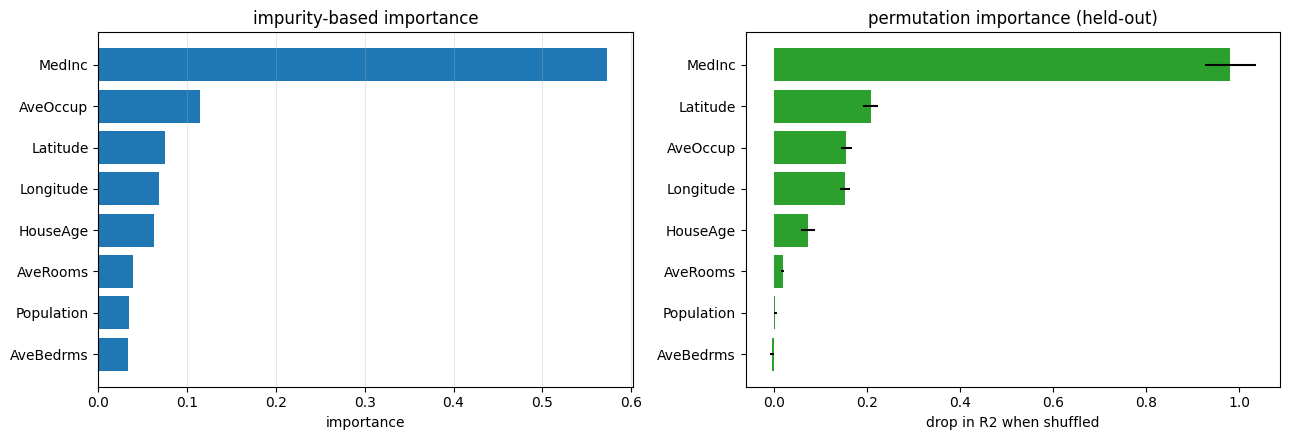

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

Xtr, Xte, ytr, yte = train_test_split(Xc, yc, test_size=0.3, random_state=0)
rf = RandomForestRegressor(n_estimators=200, random_state=0).fit(Xtr, ytr)

imp = interpretation.feature_importance_table(rf, Xc.columns)
perm = interpretation.permutation_importance_table(rf, Xte, yte, n_repeats=10, seed=0)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plotting.plot_feature_importance(imp["feature"], imp["importance"], ax=axes[0], title="impurity-based importance")
axes[1].barh(perm["feature"][::-1], perm["importance_mean"][::-1], xerr=perm["importance_std"][::-1], color="#2ca02c")
axes[1].set_title("permutation importance (held-out)"); axes[1].set_xlabel("drop in R2 when shuffled")
plt.tight_layout(); plt.show()

## 3. 部分依存 (PDP) — 特徴を動かすと予測はどう動くか

PDP は、ある特徴を範囲全体で動かしながら **他の特徴については平均** を取った予測です。
「収入(MedInc)が上がると価格はどう上がるか」といった **限界的な効き方** が見えます。
下のスライダー(静的 HTML 可)で特徴を切り替えられます。

In [5]:
top_feats = list(imp["feature"].head(5))
frames = []
for f in top_feats:
    grid, avg = interpretation.partial_dependence_values(rf, Xte, f, grid_resolution=40)
    frames.append(go.Frame(name=f, data=[go.Scatter(x=list(grid), y=list(avg), mode="lines",
                                                     line={"color": "#1f77b4", "width": 3})],
                           layout={"title": f"partial dependence: {f}"}))
fig = go.Figure(data=frames[0].data, frames=frames)
steps = [{"args": [[f.name], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate"}],
          "label": f.name, "method": "animate"} for f in frames]
fig.update_layout(sliders=[{"steps": steps, "currentvalue": {"prefix": "feature = "}}],
                  title=f"partial dependence: {top_feats[0]}", width=720, height=440,
                  xaxis_title="feature value", yaxis_title="predicted house value (avg)",
                  margin={"l": 60, "r": 20, "t": 60, "b": 40})
fig.show()

## 4. ICE — 個体ごとの条件付き期待

PDP は平均なので、個体差を隠します。**ICE** は 1 行ごとに「その特徴だけ動かしたときの予測曲線」を描きます。
曲線が **平行** なら効き方は皆同じ。**広がる** なら、その特徴の効果は他の特徴に依存(=交互作用)します。

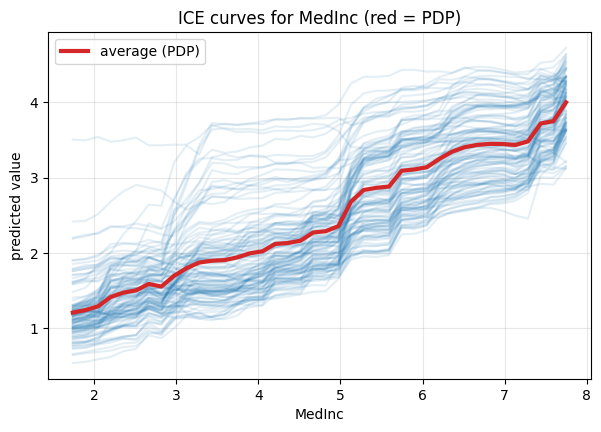

In [6]:
grid, ice = interpretation.ice_curves(rf, Xte.iloc[:120], "MedInc", grid_resolution=40)
fig, ax = plt.subplots(figsize=(7, 4.5))
for row in ice:
    ax.plot(grid, row, color="#1f77b4", alpha=0.12)
ax.plot(grid, ice.mean(0), color="#d62728", lw=3, label="average (PDP)")
ax.set_xlabel("MedInc"); ax.set_ylabel("predicted value"); ax.set_title("ICE curves for MedInc (red = PDP)")
ax.legend(); ax.grid(alpha=0.3); plt.show()

### 2 特徴の交互作用を見る (2-way PDP)

2 つの特徴を同時に動かした部分依存をヒートマップで見ると、**交互作用**(片方の効きがもう片方に依存)が
等高線の傾き・うねりとして現れます。

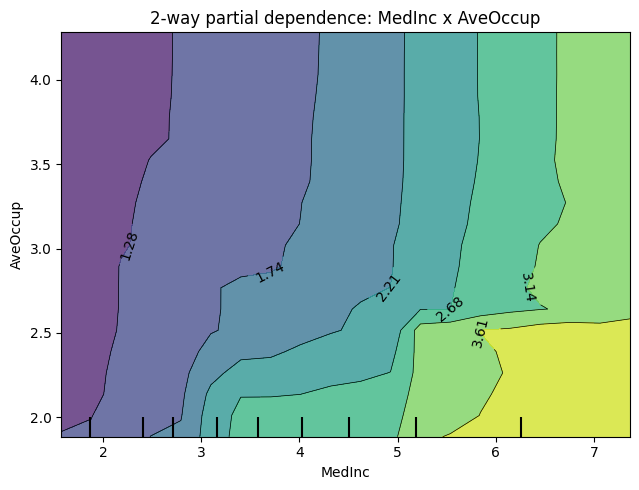

In [7]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(6.5, 5))
PartialDependenceDisplay.from_estimator(
    rf, Xte.iloc[:500], [("MedInc", "AveOccup")], ax=ax, grid_resolution=20
)
ax.set_title("2-way partial dependence: MedInc x AveOccup")
plt.tight_layout(); plt.show()

## 5. 相関した特徴は重要度を不安定にする

ほぼ同じ情報を持つ 2 特徴があると、モデルはどちらに功績を割り当てるか決められません。
ブートストラップで線形回帰を繰り返すと、各係数は大きく揺れるのに **和は安定** します。

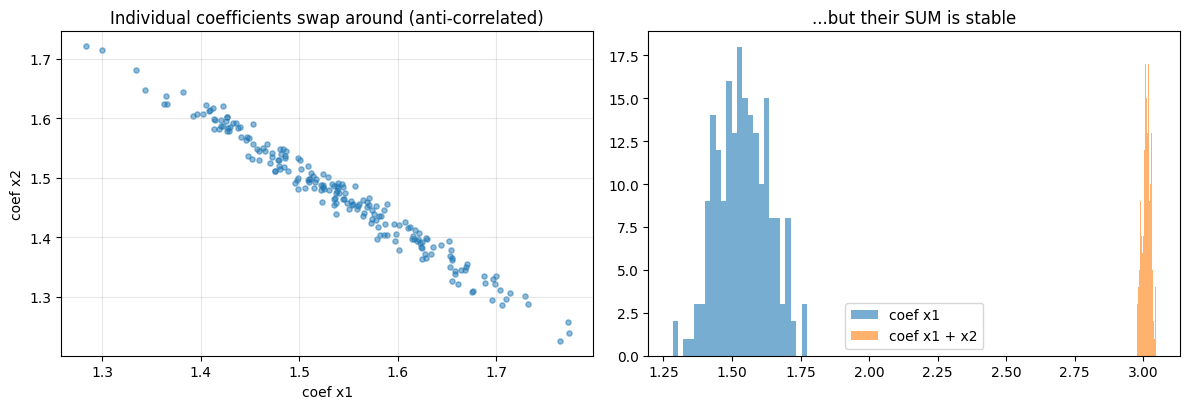

std(coef_x1) = 0.10   std(coef_sum) = 0.01


In [8]:
demo = interpretation.correlated_feature_demo(n=400, n_runs=200, corr=0.99, seed=0)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].scatter(demo["coef_x1"], demo["coef_x2"], s=14, alpha=0.5, color="#1f77b4")
axes[0].set_xlabel("coef x1"); axes[0].set_ylabel("coef x2")
axes[0].set_title("Individual coefficients swap around (anti-correlated)"); axes[0].grid(alpha=0.3)
axes[1].hist(demo["coef_x1"], bins=25, alpha=0.6, label="coef x1")
axes[1].hist(demo["coef_sum"], bins=25, alpha=0.6, label="coef x1 + x2")
axes[1].set_title("...but their SUM is stable"); axes[1].legend()
plt.tight_layout(); plt.show()
print(f"std(coef_x1) = {demo['coef_x1'].std():.2f}   std(coef_sum) = {demo['coef_sum'].std():.2f}")

## 6. 相関 ≠ 因果

モデルにとって重要な特徴が、現実の **原因** とは限りません。下では、**交絡因子 z** が
特徴 `proxy` とターゲットの両方を動かします。`proxy` 自体は $y$ に直接効かないのに、
モデルは強く依存します。「proxy を変えれば $y$ が変わる」と読むのは誤りです。

In [9]:
rng = np.random.default_rng(1)
n = 1500
z = rng.standard_normal(n)                 # hidden confounder
proxy = z + 0.3 * rng.standard_normal(n)   # driven by z, but does NOT cause y
cause = rng.standard_normal(n)             # a genuine driver of y
y_conf = 2.0 * z + 1.5 * cause + 0.3 * rng.standard_normal(n)
Xconf = pd.DataFrame({"proxy": proxy, "cause": cause})

m = make_pipeline(StandardScaler(), LinearRegression()).fit(Xconf, y_conf)
ct = interpretation.coefficient_table(m.named_steps["linearregression"], Xconf.columns)
print(ct.to_string(index=False))
print("\n'proxy' looks important (it tracks the confounder z), but intervening on it would NOT change y.")

feature  coefficient  abs_coefficient
  proxy     1.940629         1.940629
  cause     1.491783         1.491783

'proxy' looks important (it tracks the confounder z), but intervening on it would NOT change y.


## 7. 反実仮想 (counterfactual) の見方

「この予測を変えるには、何をどれだけ変えればよいか?」— 1 つの特徴を動かして予測がしきい値を越える点を探します。
乳がんデータで、1 人の患者の 1 特徴を動かしたときの **悪性確率** を見ます(本質的には ICE の分類版)。

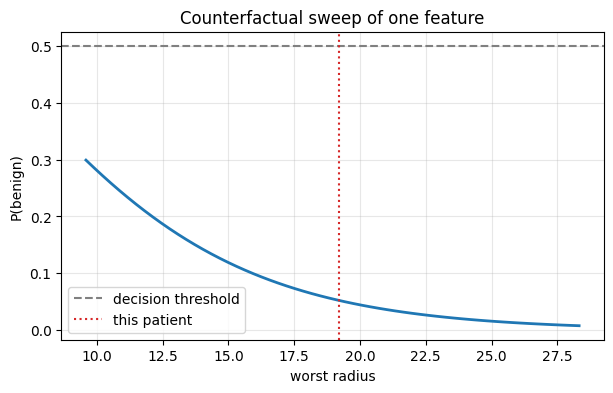

In [10]:
from sklearn.linear_model import LogisticRegression

bc = datasets.load_breast_cancer_dataset()
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(bc.data, bc.target)
patient = bc.data.iloc[[10]].copy()
feature = "worst radius"
lo, hi = bc.data[feature].quantile(0.02), bc.data[feature].quantile(0.98)
grid = np.linspace(lo, hi, 60)
probs = []
for v in grid:
    row = patient.copy(); row[feature] = v
    probs.append(clf.predict_proba(row)[0, 1])   # P(class 1 = benign)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(grid, probs, lw=2, color="#1f77b4")
ax.axhline(0.5, color="gray", ls="--", label="decision threshold")
ax.axvline(patient[feature].iloc[0], color="#d62728", ls=":", label="this patient")
ax.set_xlabel(feature); ax.set_ylabel("P(benign)"); ax.set_title("Counterfactual sweep of one feature")
ax.legend(); ax.grid(alpha=0.3); plt.show()

## 8. SHAP(任意・補足)

**SHAP** は協力ゲーム理論の Shapley 値で、各特徴が 1 件の予測に与えた寄与を **加法的に** 分解します
($\hat y = \text{base} + \sum_j \phi_j$)。任意依存なので、入っていれば要約図を出し、無ければスキップします。
直感は「permutation importance を 1 件単位・寄与の足し算で精密化したもの」です。

In [11]:
try:
    import shap
    expl = shap.TreeExplainer(rf)
    sv = expl.shap_values(Xte.iloc[:200])
    shap.summary_plot(sv, Xte.iloc[:200], show=True)
except Exception as e:
    print("SHAP not installed — skipping (pip install shap to enable).", type(e).__name__)
    print("Concept: SHAP attributes each prediction additively across features (sums to the prediction).")

SHAP not installed — skipping (pip install shap to enable). ModuleNotFoundError
Concept: SHAP attributes each prediction additively across features (sums to the prediction).


## 9. まとめ

- グローバル: **係数 / 重要度 / permutation importance** で「効く特徴」を見る。不純度重要度は偏るので permutation と併用。
- ローカル/形状: **PDP** は平均的な効き方、**ICE** は個体差(交互作用)を見せる。
- **相関した特徴** は係数・重要度を不安定にする(和は安定)。
- **相関 ≠ 因果**: モデルが使う特徴 = 原因ではない。交絡に注意。
- 反実仮想は「何を変えれば予測が変わるか」を示すが、これも **モデル上の話** で介入の効果保証ではない。

## 10. Exercises

1. 線形係数の `proxy/cause` 例で、`proxy` を除いて学習し直すと `cause` の係数がどう変わるか観察せよ。
2. permutation importance の `n_repeats` を 2 と 50 にして、誤差棒(std)がどう変わるか見よ。
3. PDP スライダーで、単調でない(山なりの)効き方をする特徴を探せ。
4. ICE が大きく広がる特徴を見つけ、交互作用の相手を推測せよ。
5. (発展)反実仮想の対象特徴を変え、最も少ない変化で予測が反転する特徴を見つけよ。

## 11. Common Mistakes

- **不純度重要度を因果や唯一の真実として扱う。** 偏りがある。permutation と併用、相関に注意。
- **相関した特徴の個別係数を真に受ける。** 不安定。グループで解釈する。
- **「重要 = 原因」と読む。** 交絡・代理変数の可能性。介入の根拠にしない。
- **PDP を個体の予測説明に使う。** PDP は平均。個体は ICE/SHAP で。

## 12. Advanced Notes

**PDP の前提。** 部分依存は「動かす特徴と残りの特徴が独立」を暗黙に仮定する。強く相関していると、
PDP は現実にあり得ない組み合わせ(例: 部屋数 0 で面積最大)上で予測を平均してしまい、誤解を生む。
相関が強い場合は **Accumulated Local Effects (ALE)** など、条件付きの手法が安全。